**Introduction to Signal Processing**

**Libraries**

- `numpy` — number arrays
- `scipy` — ready-made signal processing functions
- `matplotlib` — plots

Run the cell below to install them.

In [2]:
!pip install numpy scipy matplotlib


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, ifft, fftfreq
from time import time

np.random.seed(42)

**1. Sampling**

A signal is an array of numbers taken at regular time intervals $T$: $x[n] = x(nT)$, $f_s = 1/T$.

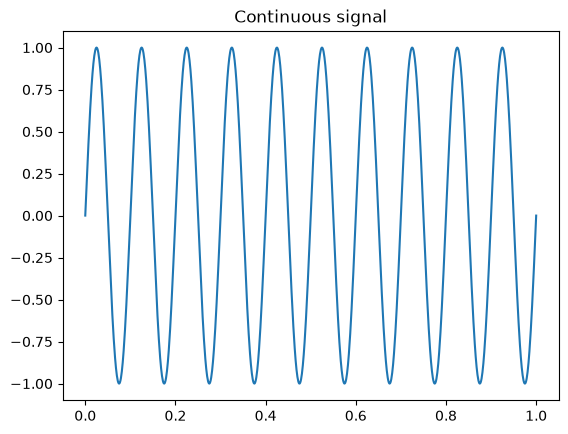

In [4]:
# continuous signal, 5 Hz
t = np.linspace(0, 1, 1000)
x = np.sin(2 * np.pi * 10 * t)

plt.plot(t, x)
plt.title('Continuous signal')
plt.show()

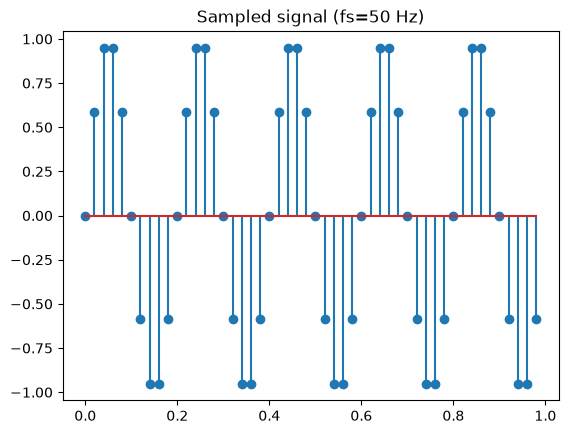

In [5]:
# the same signal, sampled at only 20 points per second (fs=20 Hz)
fs = 50
t_disc = np.arange(0, 1, 1/fs)
x_disc = np.sin(2 * np.pi * 5 * t_disc)

plt.stem(t_disc, x_disc)
plt.title(f'Sampled signal (fs={fs} Hz)')
plt.show()

**Sampling rate vs. period** -- `fs` = how often we check (bigger = more often = more data). `T = 1/fs` = the time gap between checks (bigger = less often = less data). They're just inverses of each other.

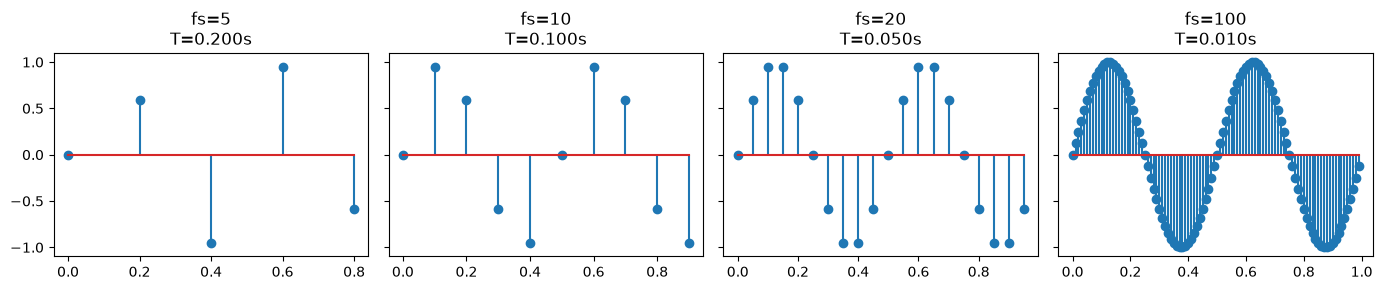

In [6]:
# sampling rate vs. period -- same signal, checked at 4 different rates
fig, axes = plt.subplots(1, 4, figsize=(14, 3), sharey=True)

for ax, fs_example in zip(axes, [5, 10, 20, 100]):
    T_example = 1 / fs_example
    t_example = np.arange(0, 1, T_example)
    x_example = np.sin(2 * np.pi * 2 * t_example)  # a 2 Hz wave, just for this demo

    ax.stem(t_example, x_example)
    ax.set_title(f"fs={fs_example}\nT={T_example:.3f}s")

plt.tight_layout()
plt.show()

**Quantization** — amplitude gets discretized too, e.g. a 16-bit sensor has $2^{16}$ levels.

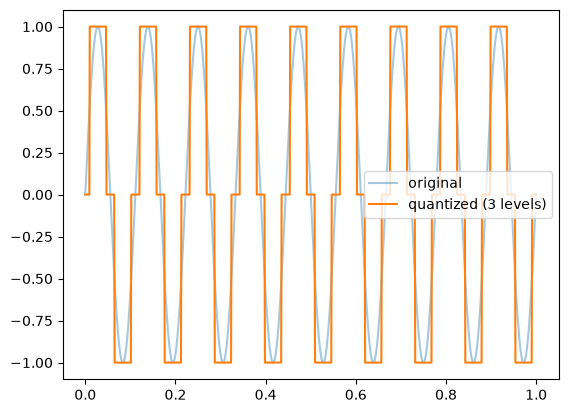

In [11]:
# round each value to the nearest of 3 allowed levels: -1, 0, 1
levels = [-1, 0, 1]

x_quant = []
for value in x:
    distances = [abs(value - lvl) for lvl in levels]
    closest_level = levels[np.argmin(distances)]
    x_quant.append(closest_level)

plt.plot(t, x, alpha=0.4, label='original')
plt.plot(t, x_quant, label='quantized (3 levels)')
plt.legend()
plt.show()

**2. Aliasing**

Nyquist-Shannon theorem: $f_s > 2 f_{\max}$. Otherwise a high frequency gets "disguised" as a lower one:

$$f_{\text{alias}} = |f_{\text{in}} - k \cdot f_s|$$

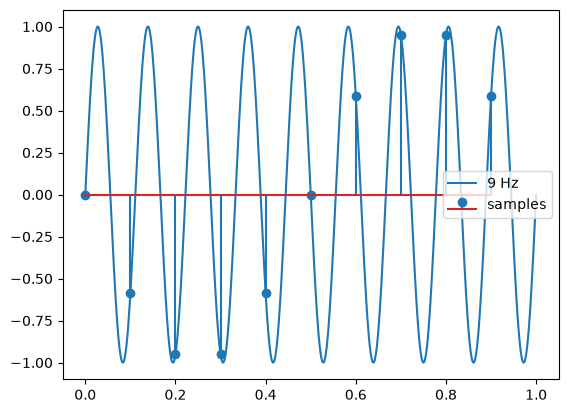

In [12]:
# 9 Hz signal, sampled at fs=10 Hz -- not enough!
f_in, fs = 9, 10
t = np.linspace(0, 1, 1000)
t_disc = np.arange(0, 1, 1/fs)

x = np.sin(2 * np.pi * f_in * t)
x_disc = np.sin(2 * np.pi * f_in * t_disc)

plt.plot(t, x, label=f'{f_in} Hz')
plt.stem(t_disc, x_disc, label='samples')
plt.legend()
plt.show()

In [13]:
# compute the alias frequency using the formula
k = round(f_in / fs)
f_alias = abs(f_in - k * fs)
print(f"f_in={f_in}, fs={fs} -> f_alias={f_alias} Hz")

f_in=9, fs=10 -> f_alias=1 Hz


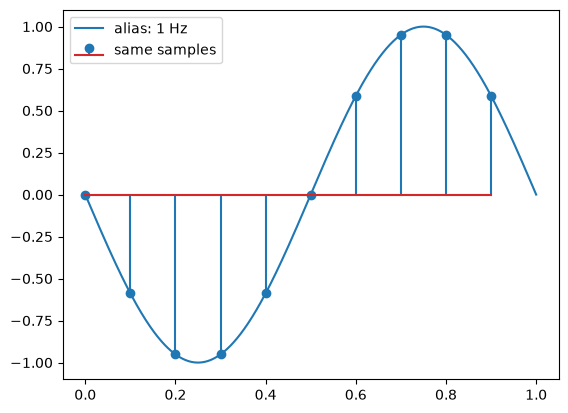

In [14]:
# these same samples look as if the signal was only f_alias Hz
# (note the + pi: at fs=10, a 9 Hz wave is a phase-inverted 1 Hz wave, not an identical one)
x_alias = np.sin(2 * np.pi * f_alias * t + np.pi)

plt.plot(t, x_alias, label=f'alias: {f_alias} Hz')
plt.stem(t_disc, x_disc, label='same samples')
plt.legend()
plt.show()

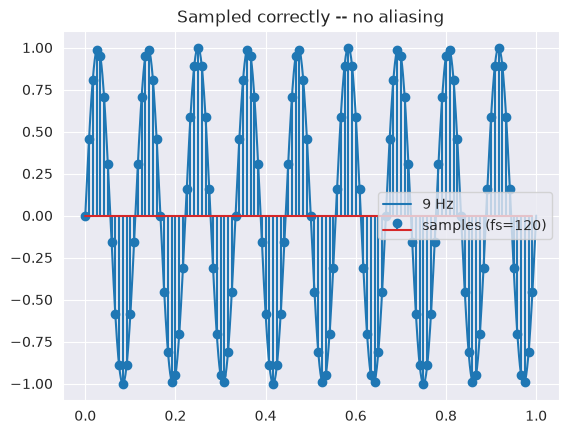

In [43]:
# now apply the rule properly: fs must be > 2 * f_in
f_in = 9
fs_safe = 120 # 30 > 2*9=18, so this is safe

t_disc_safe = np.arange(0, 1, 1/fs_safe)
x_disc_safe = np.sin(2 * np.pi * f_in * t_disc_safe)

plt.plot(t, x, label=f'{f_in} Hz')
plt.stem(t_disc_safe, x_disc_safe, label=f'samples (fs={fs_safe})')
plt.legend()
plt.title('Sampled correctly -- no aliasing')
plt.show()

**3. Fourier Transform**

Any signal can be decomposed into a sum of sines/cosines of different frequencies, amplitudes and phases.

| Name | Signal | Spectrum |
|---|---|---|
| Fourier transform | continuous, non-periodic | continuous |
| Fourier series | continuous, periodic | discrete |
| DFT | discrete, periodic | discrete |
| DTFT | discrete, non-periodic | continuous |

We work with the DFT: $X[k] = \sum_{n=0}^{N-1} x[n]\, e^{-j 2\pi k n / N}$.

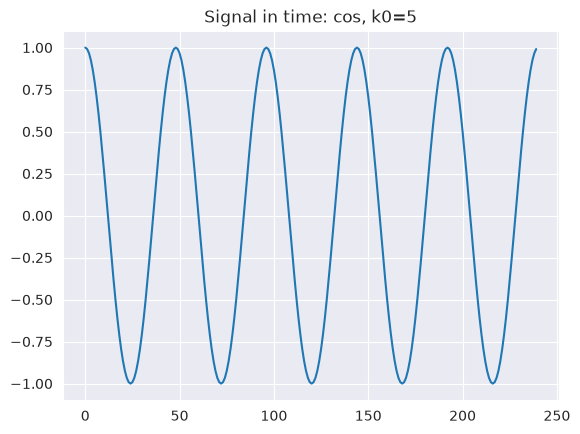

In [48]:
# a pure cosine with integer frequency k0=5
N = 240
n = np.arange(N)
k0 = 5
xk = np.cos(2 * np.pi * k0 * n / N)

plt.plot(n, xk)
plt.title('Signal in time: cos, k0=5')
plt.show()

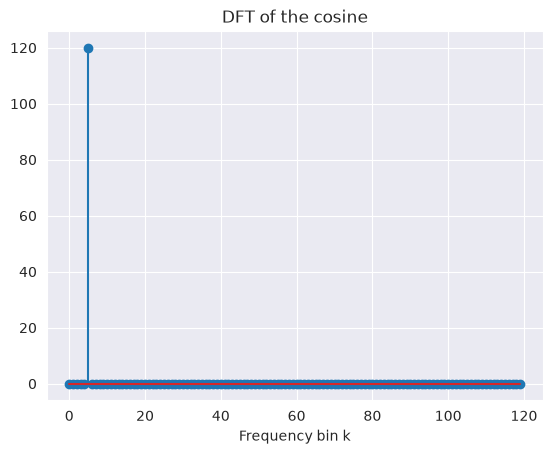

In [49]:
# its DFT -- a single sharp peak at k=5
Xk = fft(xk)
bins = np.arange(N)

plt.stem(bins[:N//2], np.abs(Xk[:N//2]))
plt.xlabel('Frequency bin k')
plt.title('DFT of the cosine')
plt.show()

In [105]:
Xk

array([-9.67904258e-15-0.00000000e+00j, -4.48784837e-15+5.03022306e-15j,
       -1.75434226e-14+3.99324999e-15j, -1.15423944e-14+4.68721882e-16j,
       -2.66423254e-14+3.85751175e-15j,  1.20000000e+02-8.28497893e-14j,
        1.90132394e-14-4.79127909e-16j,  6.97830162e-15-1.88406102e-15j,
        2.09053005e-15-1.69950108e-15j,  7.65157209e-16-4.40566997e-15j,
        1.00166732e-14-1.86214933e-15j, -3.23685951e-15-6.39663827e-15j,
        9.08232587e-15-8.96777027e-16j,  1.10685983e-15+6.67069173e-16j,
        5.24159532e-15-4.59680350e-15j,  3.07259645e-15-4.79028863e-17j,
        5.48322408e-15+5.56864345e-15j,  1.61407485e-15-9.77158309e-16j,
        1.12099639e-14+8.81716341e-15j, -4.35867652e-16+1.21551244e-14j,
       -1.62349075e-14-4.24539208e-15j,  4.64509255e-16-5.29913776e-16j,
       -1.98458025e-15-1.29285834e-15j, -7.90840269e-16-3.62072986e-15j,
       -3.14050623e-15+4.75697777e-15j, -1.89071476e-15-5.19395321e-15j,
       -1.11706600e-15-6.07412735e-15j, -2.12631671

In [108]:
# a signal with a 45-degree phase shift -- DFT should recover both amplitude and phase
phase = np.pi / 4
x_ph = 20 * np.cos(2 * np.pi * k0 * n / N + phase)
X_ph = fft(x_ph)

amp = np.abs(X_ph[k0]) / N * 2
phi = np.angle(X_ph[k0])
print(f"Amplitude ~ {amp:.2f} (expected 20)")
print(f"Phase ~ {np.degrees(phi):.1f} deg (expected {np.degrees(phase):.1f} deg)")

Amplitude ~ 20.00 (expected 20)
Phase ~ 45.0 deg (expected 45.0 deg)


In [111]:
# check that IDFT reconstructs the original signal
x_rec = ifft(X_ph).real
print("Max reconstruction error:", np.max(np.abs(x_ph - x_rec)))

Max reconstruction error: 1.0658141036401503e-14


**Properties of the Fourier Transform**

Adding two signals, scaling by a constant, or padding with zeros all change the spectrum in predictable ways.

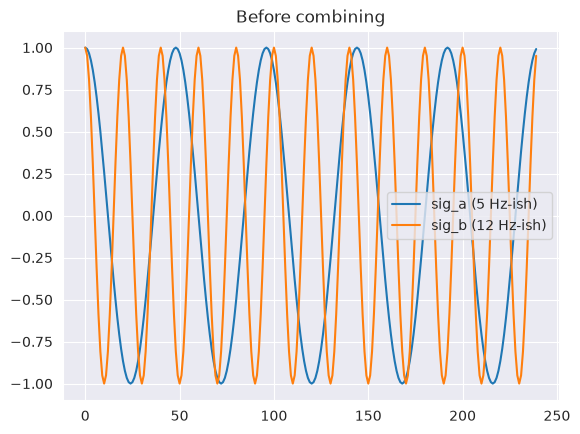

In [113]:
# two separate clean waves: one wiggles 5 times, the other 12 times
sig_a = np.cos(2 * np.pi * 5 * n / N)
sig_b = np.cos(2 * np.pi * 12 * n / N)

plt.plot(sig_a, label='sig_a (5 Hz-ish)')
plt.plot(sig_b, label='sig_b (12 Hz-ish)')
plt.legend()
plt.title('Before combining')
plt.show()

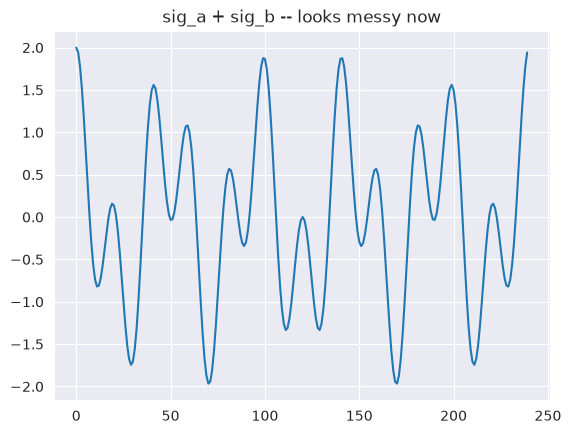

In [115]:
# glue them together, sample by sample -- now it looks like a messy, unclear shape
combined = sig_a + sig_b

plt.plot(combined)
plt.title('sig_a + sig_b -- looks messy now')
plt.show()

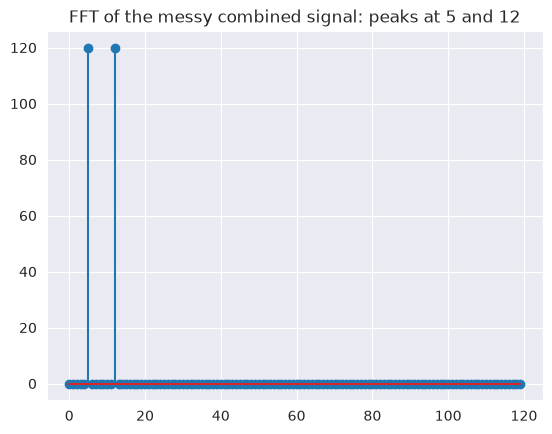

In [116]:
# run FFT on the messy combined signal -- it un-mixes it back into 5 and 12
spec_sum = fft(combined)

plt.stem(bins[:N//2], np.abs(spec_sum[:N//2]))
plt.title('FFT of the messy combined signal: peaks at 5 and 12')
plt.show()

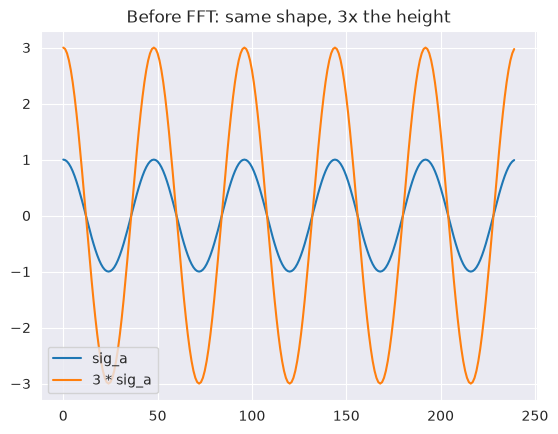

In [117]:
# the same wave, but 3x louder/taller
plt.plot(sig_a, label='sig_a')
plt.plot(3 * sig_a, label='3 * sig_a')
plt.legend()
plt.title('Before FFT: same shape, 3x the height')
plt.show()

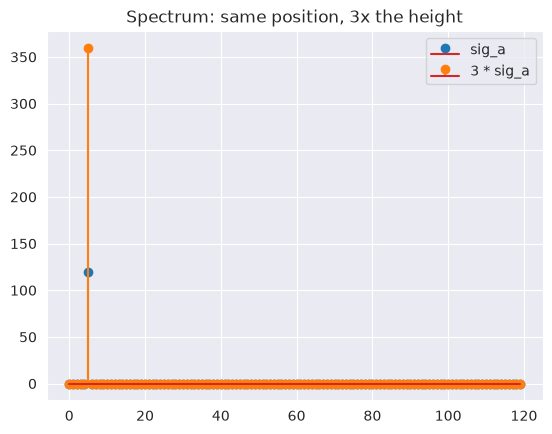

In [118]:
# FFT of each -- the spike stays at bin 5, just 3x taller
spec_a = fft(sig_a)
spec_a_scaled = fft(3 * sig_a)

plt.stem(bins[:N//2], np.abs(spec_a[:N//2]), label='sig_a')
plt.stem(bins[:N//2], np.abs(spec_a_scaled[:N//2]), linefmt='C1-', markerfmt='C1o', label='3 * sig_a')
plt.legend()
plt.title('Spectrum: same position, 3x the height')
plt.show()

In [119]:
# and the exact numbers, to confirm
print("Peak amplitude, original: ", round(np.abs(spec_a[5]), 1))
print("Peak amplitude, scaled x3:", round(np.abs(spec_a_scaled[5]), 1))

Peak amplitude, original:  120.0
Peak amplitude, scaled x3: 360.0


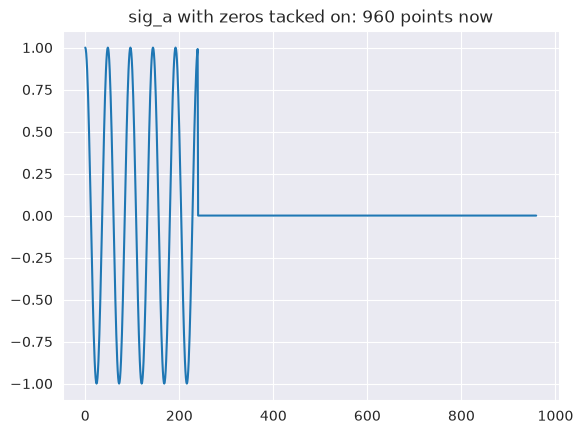

In [120]:
# pad the signal with extra zeros at the end -- same content, just longer
sig_a_padded = np.concatenate([sig_a, np.zeros(N * 3)])

plt.plot(sig_a_padded)
plt.title(f'sig_a with zeros tacked on: {len(sig_a_padded)} points now')
plt.show()

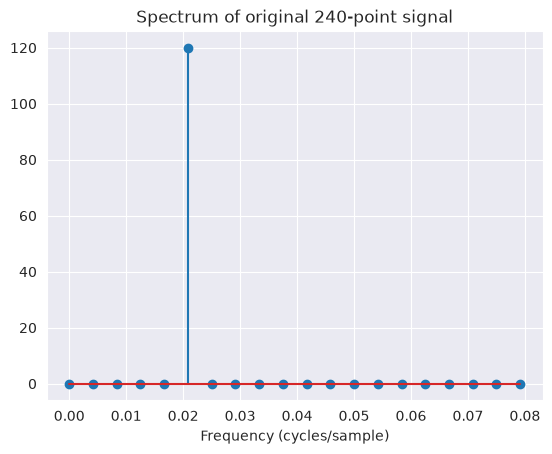

In [121]:
# FFT of the original (short) signal -- plotted against actual frequency, not raw bin number
spec_orig = fft(sig_a)
freq_axis_orig = np.arange(len(sig_a)) / len(sig_a)  # cycles per sample

plt.stem(freq_axis_orig[:20], np.abs(spec_orig[:20]))
plt.xlabel('Frequency (cycles/sample)')
plt.title(f'Spectrum of original {len(sig_a)}-point signal')
plt.show()

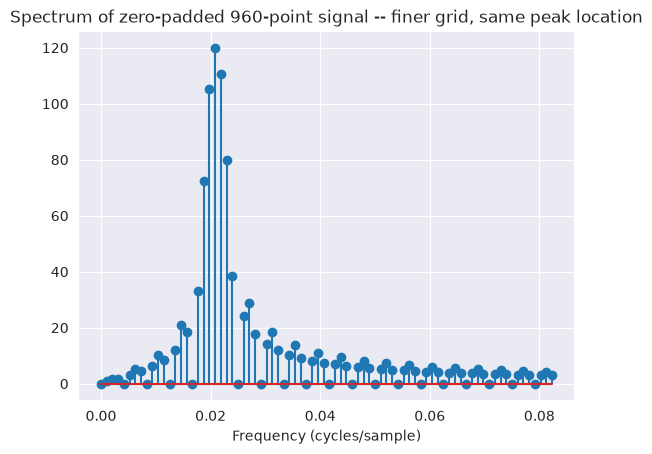

In [60]:
# FFT of the zero-padded (longer) signal -- same x-axis units, so the peak now truly lines up
spec_padded = fft(sig_a_padded)
freq_axis_padded = np.arange(len(sig_a_padded)) / len(sig_a_padded)  # cycles per sample

plt.stem(freq_axis_padded[:80], np.abs(spec_padded[:80]))
plt.xlabel('Frequency (cycles/sample)')
plt.title(f'Spectrum of zero-padded {len(sig_a_padded)}-point signal -- finer grid, same peak location')
plt.show()

**Convolution theorem**: convolving two signals in time is the same as multiplying their spectra in frequency -- `FFT(x * h) == FFT(x) * FFT(h)`.

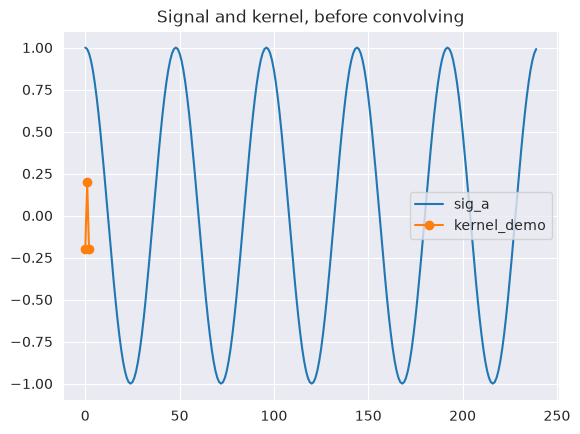

In [126]:
# signal and smoothing kernel for the convolution below
kernel_demo = np.array([-0.2, 0.2, -0.2])

plt.plot(sig_a, label='sig_a')
plt.plot(kernel_demo, 'o-', label='kernel_demo')
plt.legend()
plt.title('Signal and kernel, before convolving')
plt.show()

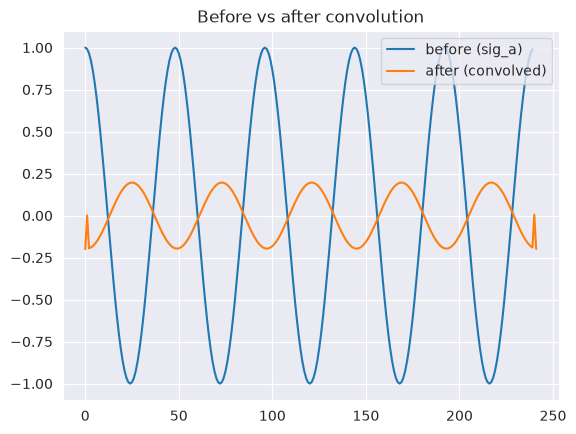

In [127]:
# method 1: direct convolution, done the normal way in the time domain
conv_direct = np.convolve(sig_a, kernel_demo, mode='full')

plt.plot(sig_a, label='before (sig_a)')
plt.plot(conv_direct, label='after (convolved)')
plt.legend()
plt.title('Before vs after convolution')
plt.show()

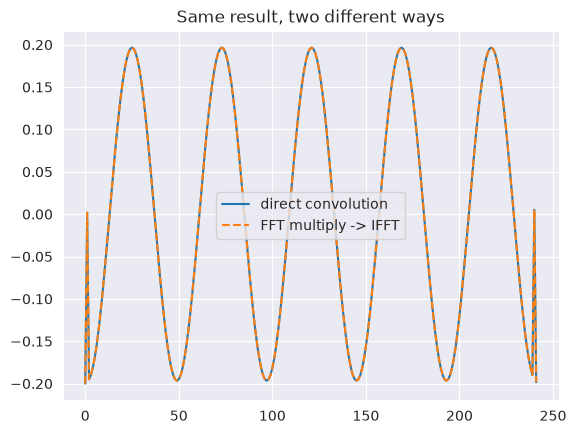

In [128]:
# method 2: FFT both, multiply the spectra, inverse-FFT back
pad_len = len(sig_a) + len(kernel_demo) - 1
conv_via_fft = ifft(fft(sig_a, pad_len) * fft(kernel_demo, pad_len)).real

plt.plot(conv_direct, label='direct convolution')
plt.plot(conv_via_fft, '--', label='FFT multiply -> IFFT')
plt.legend()
plt.title('Same result, two different ways')
plt.show()

In [129]:
# and the numeric proof: the two curves above overlap almost exactly
print("Max difference between the two methods:", np.max(np.abs(conv_direct - conv_via_fft)))

Max difference between the two methods: 2.220446049250313e-16


**5. Filtering via the DFT**

Compute the spectrum, zero out the frequencies you don't want, then inverse-transform back to time. This is what a low-pass filter does under the hood.

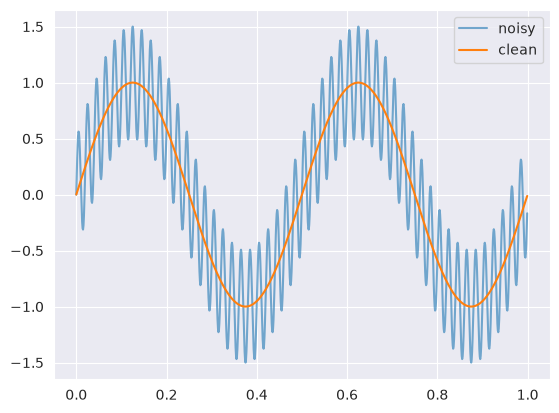

In [130]:
# a clean 2 Hz signal with 50 Hz noise added on top
fs_d = 1000
t_d = np.linspace(0, 1, fs_d, endpoint=False)
clean_sig = np.sin(2 * np.pi * 2 * t_d)
noisy_sig = clean_sig + 0.5 * np.sin(2 * np.pi * 50 * t_d)

plt.plot(t_d, noisy_sig, alpha=0.6, label='noisy')
plt.plot(t_d, clean_sig, label='clean')
plt.legend()
plt.show()

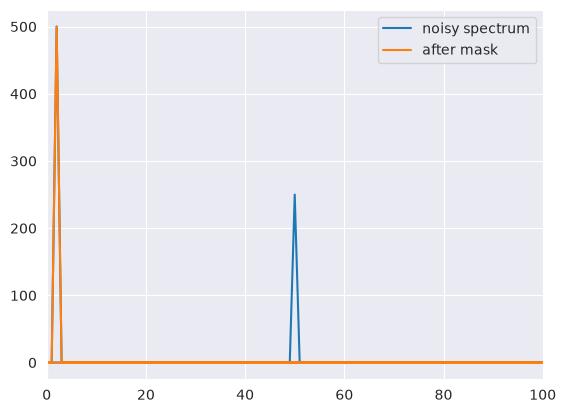

In [131]:
# spectrum before and after zeroing out everything above 40 Hz
spec_d = fft(noisy_sig)
freqs_d = fftfreq(len(t_d), 1/fs_d)
mask_d = np.abs(freqs_d) < 40
spec_filtered = spec_d * mask_d

plt.plot(freqs_d, np.abs(spec_d), label='noisy spectrum')
plt.plot(freqs_d, np.abs(spec_filtered), label='after mask')
plt.xlim(0, 100)
plt.legend()
plt.show()

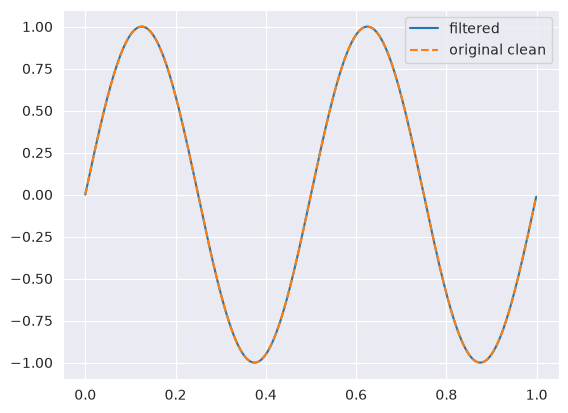

In [133]:
# back to time domain via IFFT -- the 50 Hz noise is gone
filtered_sig = ifft(spec_filtered).real

plt.plot(t_d, filtered_sig, label='filtered')
plt.plot(t_d, clean_sig, '--', label='original clean')
plt.legend()
plt.show()

**6. Spectral Leakage and Windows**

DFT assumes the signal is periodic with period $N$. If the frequency is not an integer, energy leaks into neighboring bins.

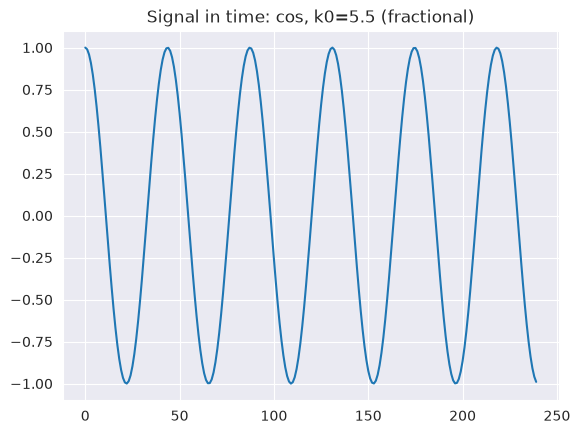

In [134]:
# fractional frequency k0=5.5 -- doesn't loop cleanly by the end of the sample window
k0_frac = 5.5
x_leak = np.cos(2 * np.pi * k0_frac * n / N)  # 5.5 cycles over N samples, not a whole number

plt.plot(n, x_leak)
plt.title('Signal in time: cos, k0=5.5 (fractional)')
plt.show()

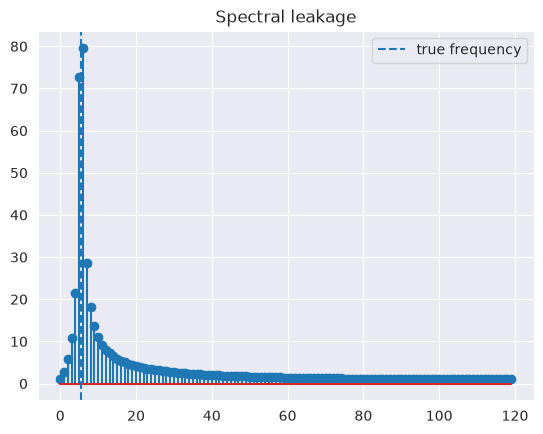

In [69]:
# its DFT -- energy spreads across nearby bins instead of one clean spike
X_leak = fft(x_leak)

plt.stem(bins[:N//2], np.abs(X_leak[:N//2]))
plt.axvline(k0_frac, linestyle='--', label='true frequency')  # sits between bins 5 and 6
plt.legend()
plt.title('Spectral leakage')
plt.show()

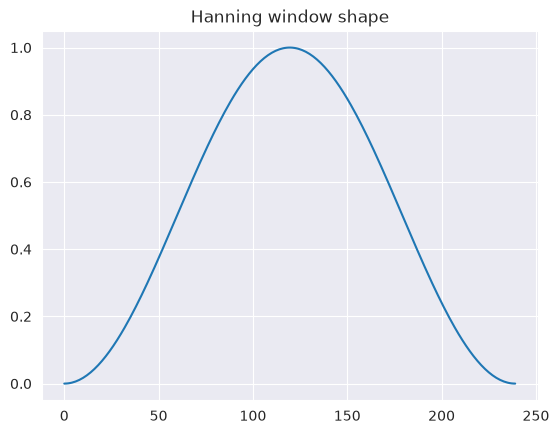

In [70]:
# the Hanning window shape: fades in, stays high, fades back out
window = np.hanning(N)  # length N to match the signal

plt.plot(window)
plt.title('Hanning window shape')
plt.show()

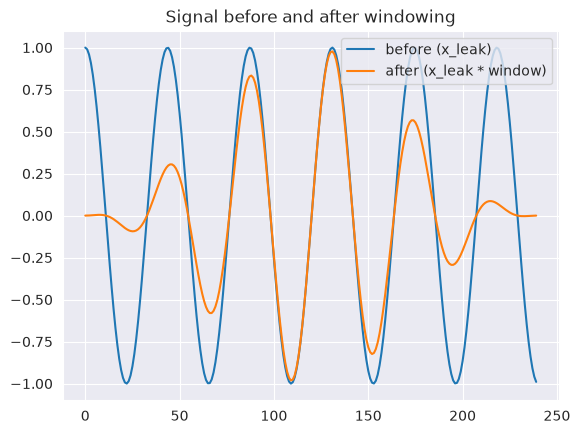

In [71]:
# what happens to the signal itself once multiplied by that window
x_win = x_leak * window  # forces both edges toward zero, middle mostly unaffected

plt.plot(x_leak, label='before (x_leak)')
plt.plot(x_win, label='after (x_leak * window)')
plt.legend()
plt.title('Signal before and after windowing')
plt.show()

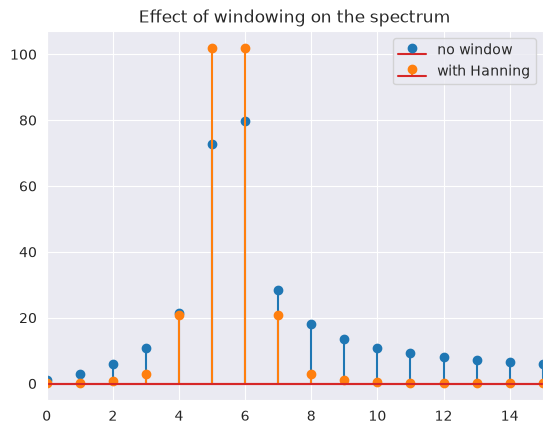

In [135]:
# now compare the spectra: windowed vs not
X_win = fft(x_win)
scale = N / np.sum(window)  # correction for the amplitude lost by fading the edges

plt.stem(bins[:N//2], np.abs(X_leak[:N//2]), label='no window')
plt.stem(bins[:N//2], np.abs(X_win[:N//2]) * scale, label='with Hanning', linefmt='C1-', markerfmt='C1o')
plt.legend()
plt.xlim(0, 15)
plt.title('Effect of windowing on the spectrum')
plt.show()  # taller/narrower peak, but the far-out leakage tail is smaller

**7. Why FFT**

A naive DFT costs $O(N^2)$. The FFT algorithm computes the same result in $O(N \log N)$.

In [136]:
def dft_naive(xv):
    Nn = len(xv)
    nn = np.arange(Nn)          # sample indices
    kk = nn.reshape((Nn, 1))    # same indices as a column, for broadcasting
    M = np.exp(-2j * np.pi * kk * nn / Nn)  # one reference wave per row (per bin)
    return np.dot(M, xv)        # multiply-and-sum for every bin at once

In [137]:
# measure the time for both approaches at growing sizes
sizes = [2**i for i in range(6, 12)]  # 64, 128, 256, ... 2048
times_naive, times_fft = [], []

for size in sizes:
    xv = np.random.randn(size)
    t0 = time(); dft_naive(xv); times_naive.append(time() - t0)  # O(N^2)
    t0 = time(); fft(xv); times_fft.append(time() - t0)          # O(N log N)

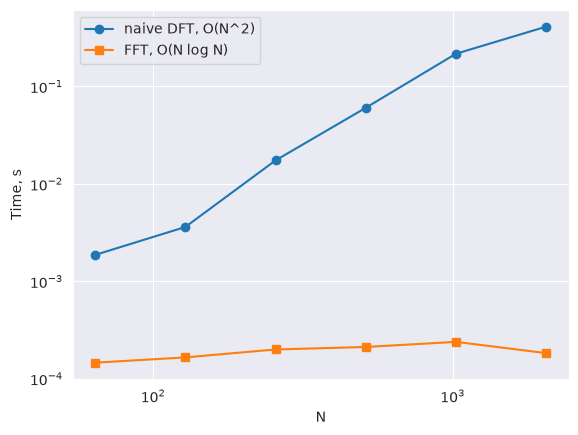

In [138]:
plt.plot(sizes, times_naive, 'o-', label='naive DFT, O(N^2)')
plt.plot(sizes, times_fft, 's-', label='FFT, O(N log N)')
plt.yscale('log')  # log scale on both axes -- makes the growth rate difference visible
plt.xscale('log')
plt.xlabel('N')
plt.ylabel('Time, s')
plt.legend()
plt.show()  # naive DFT time grows much faster as N increases

**8. Filtering**

A **FIR** filter (moving average, windowed-sinc) is a convolution with a fixed kernel -- it introduces a delay.
An **IIR** filter (PT1, Butterworth, notch) is recursive, more efficient, but can be unstable.

`scipy.signal` already has most filters and peak-detection tools built in: `butter`, `iirnotch`, `filtfilt`, `lfilter`, `find_peaks`, `find_peaks_cwt`.

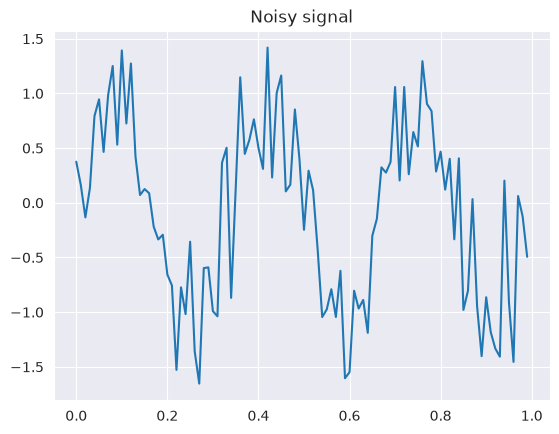

In [139]:
# noisy signal
fs = 100
t = np.arange(0, 1, 1/fs)
x_noisy = np.sin(2*np.pi*3*t) + 0.4*np.random.randn(len(t))  # 3 Hz signal + random noise

plt.plot(t, x_noisy)
plt.title('Noisy signal')
plt.show()

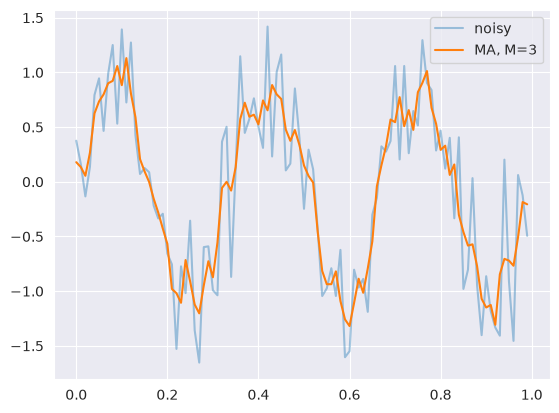

In [141]:
# FIR: moving average (average M neighboring points)
M = 3
kernel = np.ones(M) / M  # equal weight on all 5 neighbors, sums to 1
x_ma = np.convolve(x_noisy, kernel, mode='same')

plt.plot(t, x_noisy, alpha=0.4, label='noisy')
plt.plot(t, x_ma, label=f'MA, M={M}')
plt.legend()
plt.show()

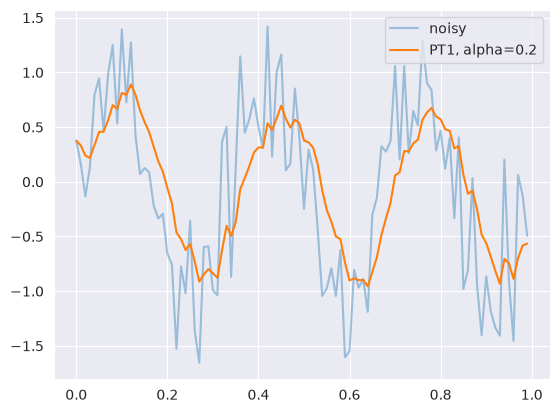

In [144]:
# IIR: PT1 (exponential smoothing) -- each output depends on the previous one
alpha = 0.2  # how much to trust the new reading vs. the smoothed history
x_pt1 = np.zeros_like(x_noisy)
x_pt1[0] = x_noisy[0]  # no history yet, start from the first raw value
for i in range(1, len(x_noisy)):
    x_pt1[i] = alpha * x_noisy[i] + (1 - alpha) * x_pt1[i-1]  # blend new + previous smoothed

plt.plot(t, x_noisy, alpha=0.4, label='noisy')
plt.plot(t, x_pt1, label=f'PT1, alpha={alpha}')
plt.legend()
plt.show()

**Windowed-sinc filter** -- an ideal low-pass in frequency is a rectangle, which in time is a sinc. Truncating and windowing it gives a practical FIR filter.

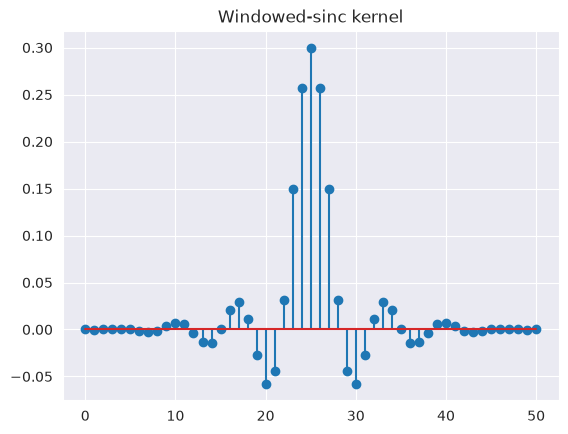

In [79]:
# build the windowed-sinc kernel
def windowed_sinc(fc, M, fs):
    nk = np.arange(M) - (M - 1) / 2  # M must be odd; center on 0
    h = np.sinc(2 * fc / fs * nk) * np.hanning(M)  # ideal lowpass shape, tapered at the edges
    return h / np.sum(h)  # normalize so gain=1 at DC

h = windowed_sinc(fc=15, M=51, fs=fs)

plt.stem(h)
plt.title('Windowed-sinc kernel')
plt.show()

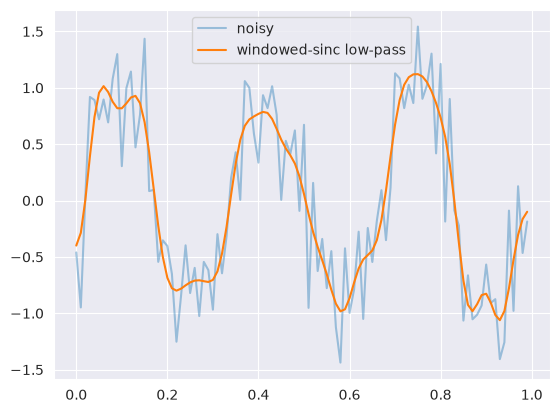

In [80]:
# apply it to the noisy signal via convolution
x_ws = np.convolve(x_noisy, h, mode='same')  # sharper cutoff than plain MA

plt.plot(t, x_noisy, alpha=0.4, label='noisy')
plt.plot(t, x_ws, label='windowed-sinc low-pass')
plt.legend()
plt.show()

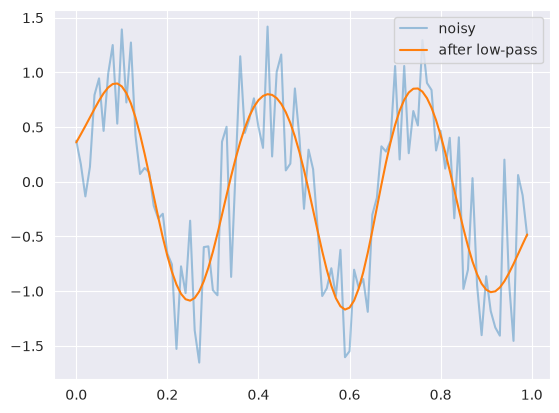

In [145]:
# ready-made IIR low-pass from scipy (Butterworth) -- removes everything above 6 Hz
b, a = signal.butter(4, 6, fs=fs, btype='low')  # order 4, cutoff 6 Hz
x_filtered = signal.filtfilt(b, a, x_noisy)  # forward+backward pass -- no phase delay

plt.plot(t, x_noisy, alpha=0.4, label='noisy')
plt.plot(t, x_filtered, label='after low-pass')
plt.legend()
plt.show()

**Notch filter** -- a narrow-band IIR filter that removes a specific frequency, e.g. 50/60 Hz mains hum.

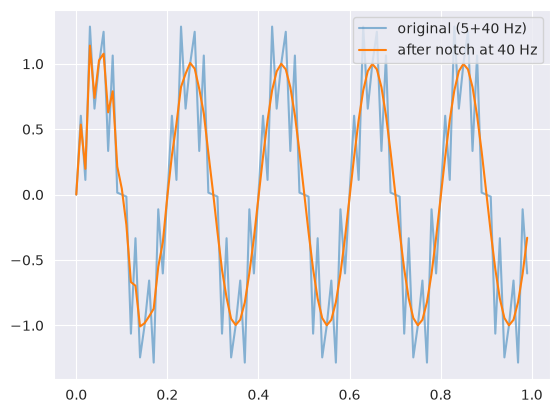

In [146]:
# signal with 5 Hz + 40 Hz interference
x_mix = np.sin(2*np.pi*5*t) + 0.5*np.sin(2*np.pi*40*t)

b, a = signal.iirnotch(w0=40, Q=10, fs=fs)  # narrow band centered on 40 Hz
x_notch = signal.lfilter(b, a, x_mix)

plt.plot(t, x_mix, alpha=0.5, label='original (5+40 Hz)')
plt.plot(t, x_notch, label='after notch at 40 Hz')
plt.legend()
plt.show()

**Impulse response and frequency response** -- send a single spike through a filter to get its impulse response; the FFT of that response shows which frequencies it passes or blocks.

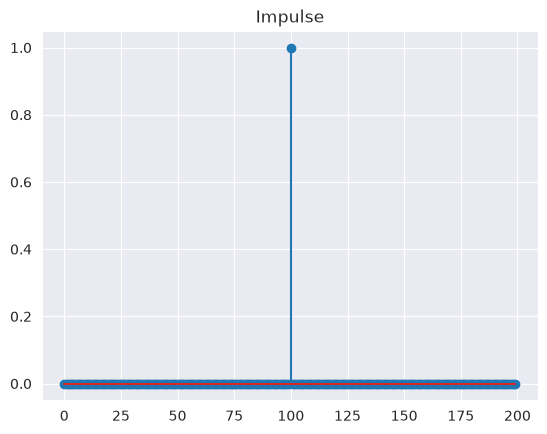

In [83]:
# an impulse: a single 1 surrounded by zeros
impulse = np.zeros(200)
impulse[100] = 1  # spike in the middle

plt.stem(impulse)
plt.title('Impulse')
plt.show()

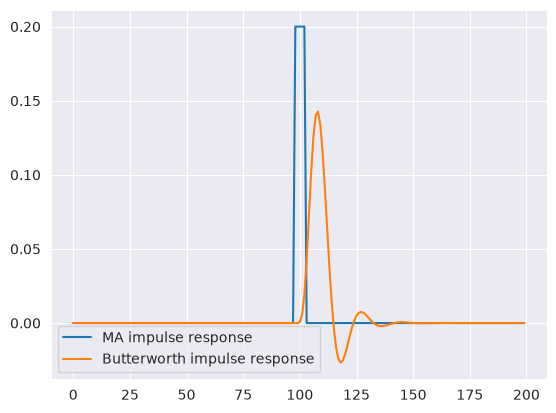

In [84]:
# pass the impulse through the MA kernel and through the Butterworth filter
b_butter, a_butter = signal.butter(4, 6, fs=fs, btype='low')

impulse_response_ma = np.convolve(impulse, kernel, mode='same')          # FIR -- flat, finite
impulse_response_butter = signal.lfilter(b_butter, a_butter, impulse)    # IIR -- decaying tail

plt.plot(impulse_response_ma, label='MA impulse response')
plt.plot(impulse_response_butter, label='Butterworth impulse response')
plt.legend()
plt.show()

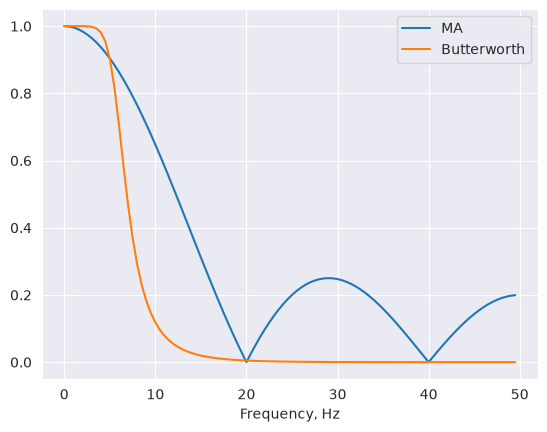

In [85]:
# FFT of each impulse response = the filter's frequency response
freq_resp_ma = fft(impulse_response_ma)
freq_resp_butter = fft(impulse_response_butter)
freqs_resp = fftfreq(len(impulse), 1/fs)

plt.plot(freqs_resp[freqs_resp >= 0], np.abs(freq_resp_ma[freqs_resp >= 0]), label='MA')
plt.plot(freqs_resp[freqs_resp >= 0], np.abs(freq_resp_butter[freqs_resp >= 0]), label='Butterworth')
plt.xlabel('Frequency, Hz')
plt.legend()
plt.show()  # Butterworth cuts off much more sharply above 6 Hz than MA

**Filtering an actual signal** -- generate a signal with a frequency above the cutoff, look at its spectrum, filter it, then look at the spectrum again. The peak above the cutoff should disappear.

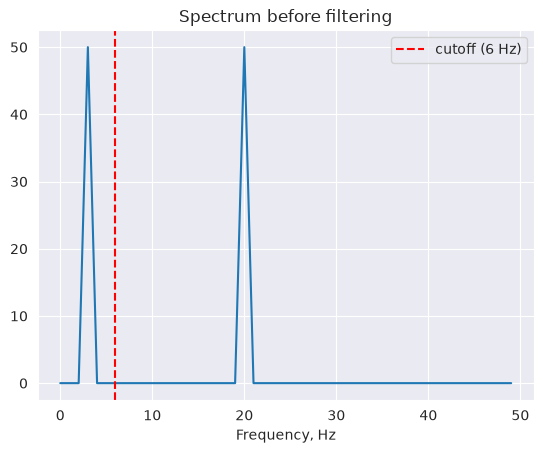

In [86]:
# a signal with one frequency below the 6 Hz cutoff, one above it
x_demo = np.sin(2*np.pi*3*t) + np.sin(2*np.pi*20*t)

spec_before = fft(x_demo)
freqs_demo = fftfreq(len(x_demo), 1/fs)

plt.plot(freqs_demo[freqs_demo >= 0], np.abs(spec_before[freqs_demo >= 0]))
plt.axvline(6, color='r', linestyle='--', label='cutoff (6 Hz)')
plt.xlabel('Frequency, Hz')
plt.legend()
plt.title('Spectrum before filtering')
plt.show()

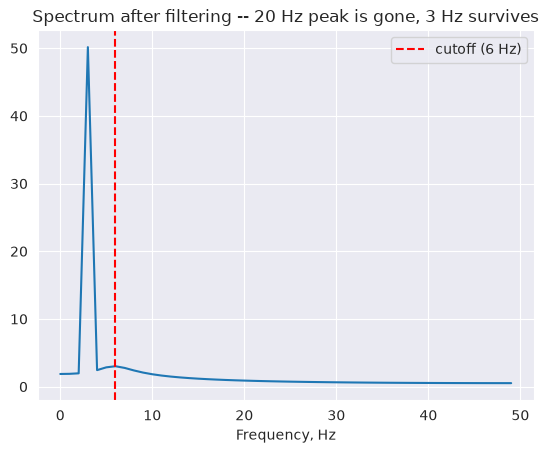

In [87]:
# apply the Butterworth filter, then look at the spectrum again -- the 20 Hz peak should be gone
x_demo_filtered = signal.filtfilt(b_butter, a_butter, x_demo)
spec_after = fft(x_demo_filtered)

plt.plot(freqs_demo[freqs_demo >= 0], np.abs(spec_after[freqs_demo >= 0]))
plt.axvline(6, color='r', linestyle='--', label='cutoff (6 Hz)')
plt.xlabel('Frequency, Hz')
plt.legend()
plt.title('Spectrum after filtering -- 20 Hz peak is gone, 3 Hz survives')
plt.show()

**Filtering a real signal (optional)** -- if you have a Betaflight blackbox log, note that the raw `.bbl` file is a binary format, not CSV. Convert it first with `blackbox_decode your_log.bbl` (from [betaflight/blackbox-tools](https://github.com/betaflight/blackbox-tools), or via the Blackbox Explorer app), which produces a `.csv` file. Point `log_path` at that resulting CSV.

In [90]:
# load a blackbox CSV export -- change the path to your own file (must be .csv, not .bbl)
import pandas as pd

log_path = "btfl_all.bbl.csv"  # <-- output of blackbox_decode, not the raw .bbl

try:
    log_df = pd.read_csv(log_path)
    print(log_df.columns.tolist())
except FileNotFoundError:
    log_df = None
    print(f"No file at '{log_path}' -- convert your .bbl with blackbox_decode first, then set log_path to the resulting .csv")

['loopIteration', 'time', 'axisP[0]', 'axisP[1]', 'axisP[2]', 'axisI[0]', 'axisI[1]', 'axisI[2]', 'axisD[0]', 'axisD[1]', 'axisF[0]', 'axisF[1]', 'axisF[2]', 'rcCommand[0]', 'rcCommand[1]', 'rcCommand[2]', 'rcCommand[3]', 'setpoint[0]', 'setpoint[1]', 'setpoint[2]', 'setpoint[3]', 'vbatLatest', 'amperageLatest', 'baroAlt', 'rssi', 'gyroADC[0]', 'gyroADC[1]', 'gyroADC[2]', 'gyroUnfilt[0]', 'gyroUnfilt[1]', 'gyroUnfilt[2]', 'accSmooth[0]', 'accSmooth[1]', 'accSmooth[2]', 'debug[0]', 'debug[1]', 'debug[2]', 'debug[3]', 'debug[4]', 'debug[5]', 'debug[6]', 'debug[7]', 'motor[0]', 'motor[1]', 'motor[2]', 'motor[3]', 'eRPM[0]', 'eRPM[1]', 'eRPM[2]', 'eRPM[3]', 'flightModeFlags', 'stateFlags', 'failsafePhase', 'rxSignalReceived', 'rxFlightChannelsValid', 'heading[0]', 'heading[1]', 'heading[2]', 'axisSum[0]', 'axisSum[1]', 'axisSum[2]', 'rcCommands[0]', 'rcCommands[1]', 'rcCommands[2]', 'rcCommands[3]', 'axisError[0]', 'axisError[1]', 'axisError[2]']


Detected log sampling rate: 2032.5 Hz


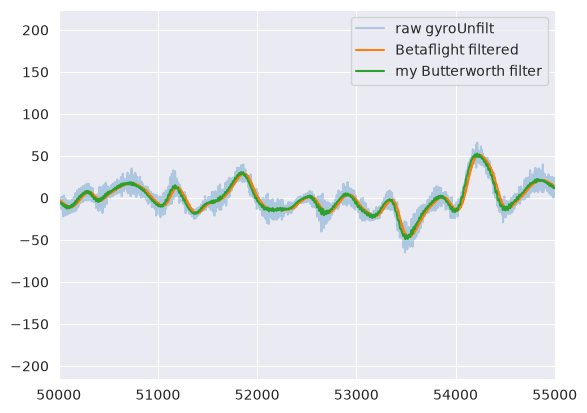

In [91]:
# apply your own low-pass to the raw gyro axis and compare with Betaflight's already-filtered column
if log_df is not None:
    raw_col = "gyroUnfilt[0]"       # raw, unfiltered gyro reading
    bf_filtered_col = "gyroADC[0]"  # Betaflight's own filtered gyro column

    # figure out the real sampling rate from the log's own time column (in microseconds)
    log_fs = 1e6 / log_df["time"].diff().median()
    print(f"Detected log sampling rate: {log_fs:.1f} Hz")

    raw_gyro = log_df[raw_col].to_numpy()
    my_filtered = signal.filtfilt(*signal.butter(4, 90, fs=log_fs, btype='low'), raw_gyro)

    plt.plot(raw_gyro, alpha=0.3, label='raw gyroUnfilt')
    plt.plot(log_df[bf_filtered_col], label='Betaflight filtered')
    plt.plot(my_filtered, label='my Butterworth filter')
    plt.legend()
    plt.xlim(50000, 55000)  # zoom in -- the difference is much clearer here
    plt.show()

**9. Peak Detection**

Simple approaches: a global threshold, a threshold relative to a moving average, or the derivative (sign change of slope).

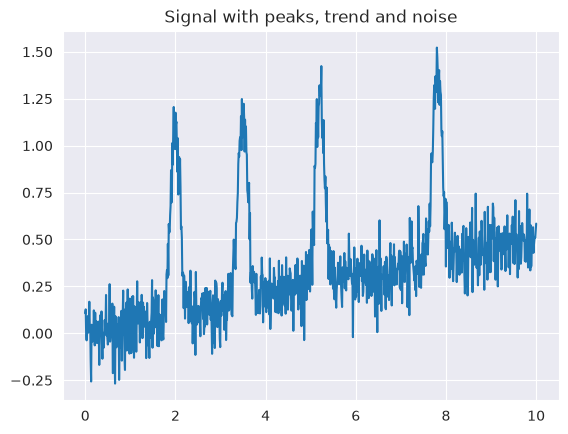

In [92]:
# signal with peaks + trend + noise
t_p = np.linspace(0, 10, 1000)
x_p = np.zeros_like(t_p)
for pos in [2.0, 3.5, 5.2, 7.8]:
    x_p += np.exp(-((t_p - pos)/0.15)**2)  # narrow gaussian bump at each position
x_p += 0.1 * np.random.randn(len(t_p))  # random noise
x_p += 0.05 * t_p  # slow upward drift

plt.plot(t_p, x_p)
plt.title('Signal with peaks, trend and noise')
plt.show()

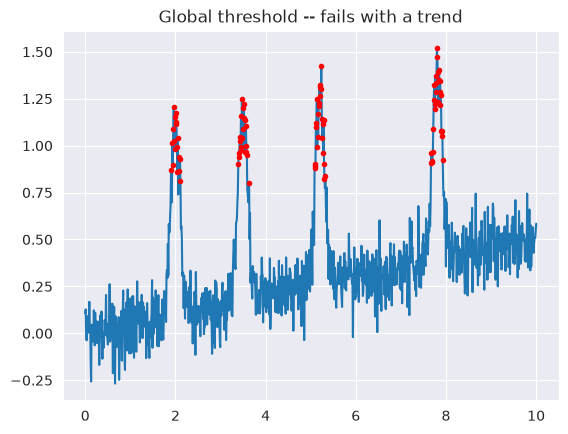

In [93]:
# naive approach -- global threshold: the trend causes it to miss early peaks and catch junk at the end
naive_peaks = np.where(x_p > 0.8)[0]  # fixed cutoff, ignores the rising baseline

plt.plot(t_p, x_p)
plt.plot(t_p[naive_peaks], x_p[naive_peaks], 'r.')
plt.title('Global threshold -- fails with a trend')
plt.show()

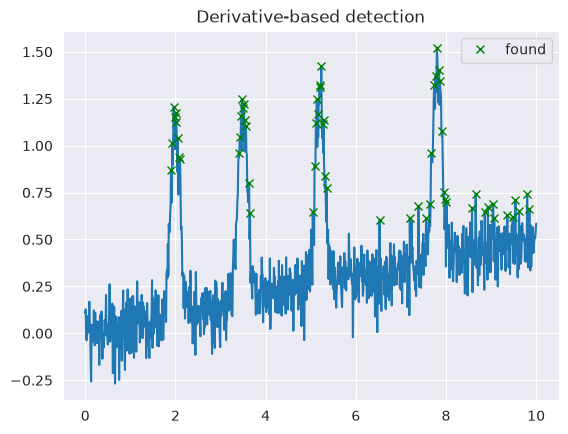

In [94]:
# derivative approach: a peak is where the slope goes from positive to negative
dx = np.diff(x_p)  # slope between consecutive points
candidates = np.where((dx[:-1] >= 0) & (dx[1:] < 0))[0] + 1  # sign change: up then down

A_thresh = 0.6
peaks_der = [i for i in candidates if x_p[i] > A_thresh]  # drop weak/noisy candidates

plt.plot(t_p, x_p)
plt.plot(t_p[peaks_der], x_p[peaks_der], 'gx', label='found')
plt.legend()
plt.title('Derivative-based detection')
plt.show()

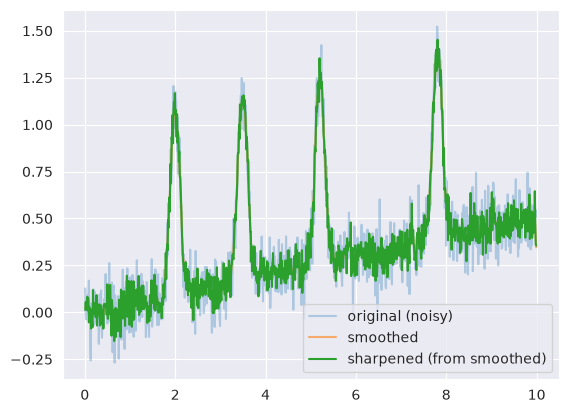

In [95]:
# second-derivative sharpening amplifies noise badly if applied directly -- smooth first, then sharpen
x_smooth = np.convolve(x_p, np.ones(9)/9, mode='same')  # light moving-average to tame the noise

d2x = np.diff(x_smooth, n=2)  # curvature (rate of change of the slope)
x_sharp = x_smooth[1:-1] - 2.0 * d2x  # subtracting curvature narrows and heightens peaks

plt.plot(t_p[1:-1], x_p[1:-1], alpha=0.3, label='original (noisy)')
plt.plot(t_p[1:-1], x_smooth[1:-1], alpha=0.6, label='smoothed')
plt.plot(t_p[1:-1], x_sharp, label='sharpened (from smoothed)')
plt.legend()
plt.show()

**scipy.signal.find_peaks** -- parameters: `height`, `prominence`, `width`, `distance`. `Prominence` measures how much a peak stands out from its surroundings, so it handles trends better than a plain threshold.

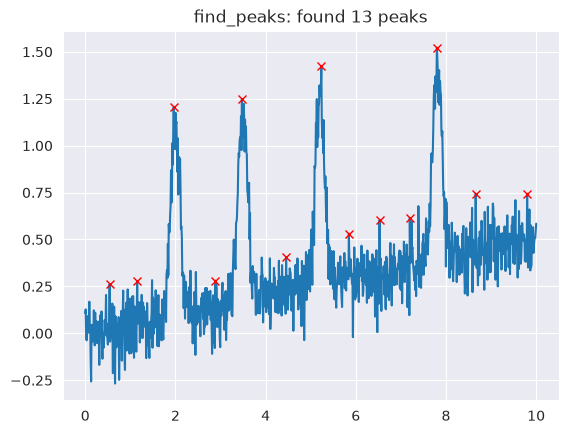

Prominence of each peak: [0.51850111 0.40916547 1.32063667 0.35450053 1.2842617  0.38168042
 1.44381639 0.39457824 0.50497039 0.41628698 1.32032016 0.51225646
 0.40867746]


In [148]:
peaks, props = signal.find_peaks(x_p, prominence=0.3, distance=50)  # prominence ignores the trend

plt.plot(t_p, x_p)
plt.plot(t_p[peaks], x_p[peaks], 'rx')
plt.title(f'find_peaks: found {len(peaks)} peaks')
plt.show()

print("Prominence of each peak:", props['prominences'])

**Wavelet detector (CWT)** -- `find_peaks_cwt` tries several widths at once, useful on noisier signals.

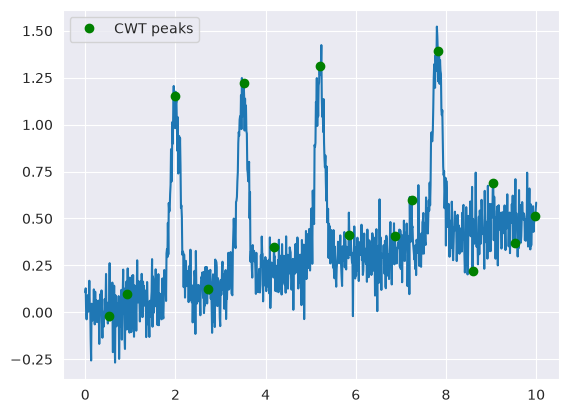

In [97]:
widths = np.arange(5, 30)  # try many peak widths at once
peaks_cwt = signal.find_peaks_cwt(x_p, widths)

plt.plot(t_p, x_p)
plt.plot(t_p[peaks_cwt], x_p[peaks_cwt], 'go', label='CWT peaks')
plt.legend()
plt.show()

**Bonus: 2D FFT on images** -- everything above works in 2D too. An image is just a 2D array of numbers, so it has its own 2D spectrum, and spatial filters (blur, edge detectors) have a frequency-domain shape just like the 1D filters did.

In [98]:
!pip install opencv-python


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [149]:
import cv2

# a few common 2D image filters
mean_filter = np.ones((3, 3))

gk = cv2.getGaussianKernel(5, 10)
gaussian = gk * gk.T

laplacian = np.array([[0, 1, 0],
                       [1, -4, 1],
                       [0, 1, 0]])

sobel_x = np.array([[-1, 0, 1],
                     [-2, 0, 2],
                     [-1, 0, 1]])

sobel_y = sobel_x.T

scharr_x = np.array([[-3, 0, 3],
                      [-10, 0, 10],
                      [-3, 0, 3]])

filters = [mean_filter, gaussian, laplacian, sobel_x, sobel_y, scharr_x]
filter_names = ['mean', 'gaussian', 'laplacian', 'sobel_x', 'sobel_y', 'scharr_x']

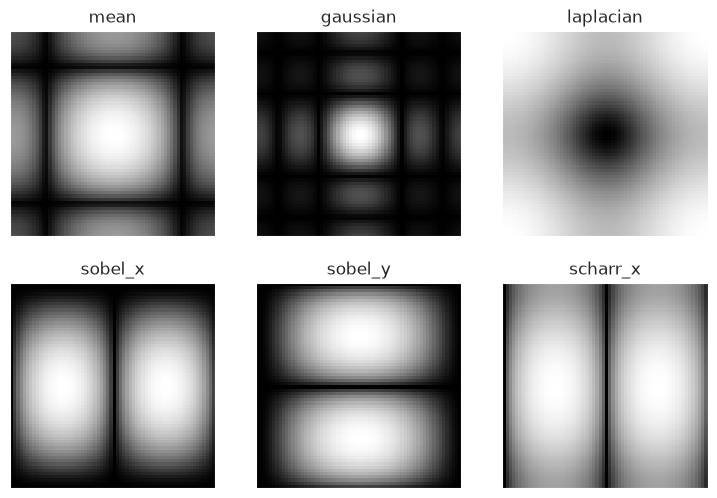

In [150]:
# the 2D FFT magnitude of each filter -- this is its frequency response
fft_filters = [np.fft.fft2(f, (64, 64)) for f in filters]
fft_shift = [np.fft.fftshift(f) for f in fft_filters]
mag_spectrum = [np.log(np.abs(f) + 1) for f in fft_shift]

fig, axes = plt.subplots(2, 3, figsize=(9, 6))
for ax, spec, name in zip(axes.ravel(), mag_spectrum, filter_names):
    ax.imshow(spec, cmap='gray')
    ax.set_title(name)
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()

Now filter an actual image the same way as the 1D signal earlier: 2D FFT, mask out high frequencies, inverse FFT.

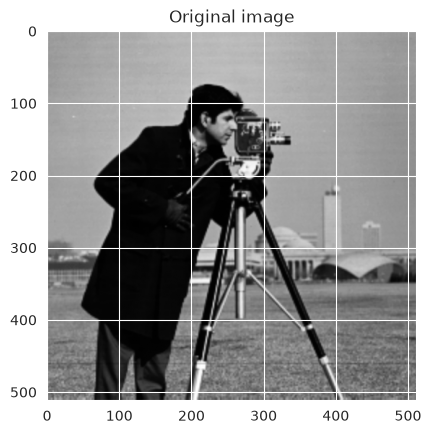

In [101]:
# load an image -- change the path to your own, or let it fall back to a synthetic one
img_path = "cameraman.png"

img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
if img is None:
    print(f"No image at '{img_path}' -- using a synthetic test image instead")
    img = np.zeros((256, 256), np.uint8)
    cv2.rectangle(img, (60, 60), (200, 200), 255, -1)
    cv2.circle(img, (128, 128), 40, 0, -1)

plt.imshow(img, cmap='gray')
plt.title('Original image')
plt.show()

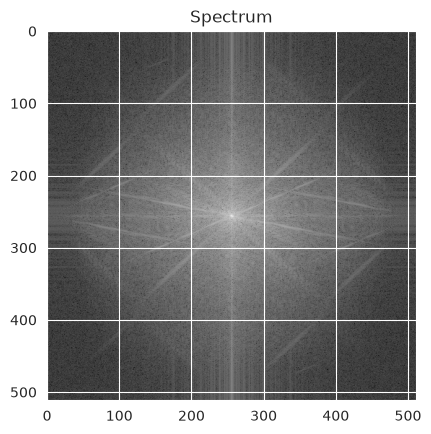

In [102]:
# 2D FFT of the image, shifted so low frequencies sit in the center
dft = cv2.dft(np.float32(img), flags=cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)

plt.imshow(np.log(cv2.magnitude(dft_shift[:, :, 0], dft_shift[:, :, 1]) + 1), cmap='gray')
plt.title('Spectrum')
plt.show()

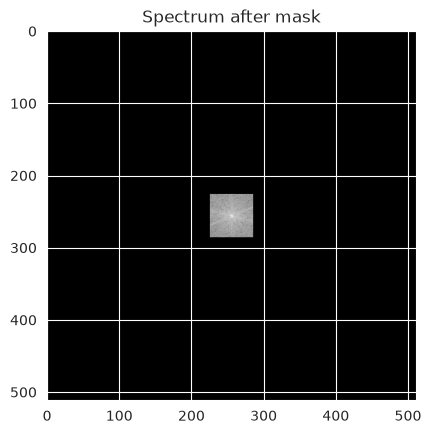

In [103]:
# mask: keep only a square of low frequencies in the center, zero out the rest
rows, cols = img.shape
crow, ccol = rows // 2, cols // 2

mask = np.zeros((rows, cols, 2), np.uint8)
mask[crow-30:crow+30, ccol-30:ccol+30] = 1
fshift = dft_shift * mask

plt.imshow(np.log(cv2.magnitude(fshift[:, :, 0], fshift[:, :, 1]) + 1), cmap='gray')
plt.title('Spectrum after mask')
plt.show()

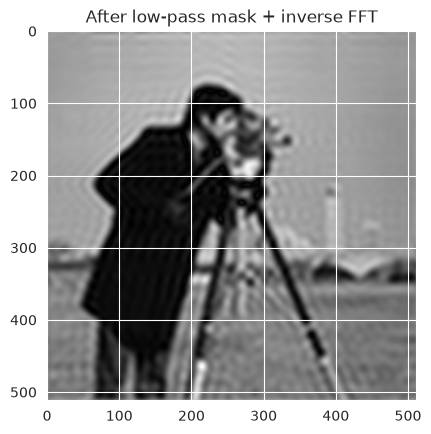

In [104]:
# inverse FFT back to the image -- a blurred version, since fine (high-frequency) detail was removed
f_ishift = np.fft.ifftshift(fshift)
img_back = cv2.idft(f_ishift)
img_back = cv2.magnitude(img_back[:, :, 0], img_back[:, :, 1])

plt.imshow(img_back, cmap='gray')
plt.title('After low-pass mask + inverse FFT')
plt.show()

**Practice**

1. Sample the note A (440 Hz) at `fs=800` Hz -- what frequency will you hear?
2. Separate two close frequencies (10 Hz and 10.5 Hz) with the DFT -- with and without a window.
3. Compare MA, PT1, windowed-sinc and `butter` on the same noisy signal -- which gives the smallest delay?
4. Find peaks on a signal with both a trend and noise, tuning `prominence`/`distance`.
5. Why do we see mirrored frequencies above N/2 in an FFT, and when is it safe to discard them?